# SKAB Dataset — EDA & Preprocessing
**Skoltech Anomaly Benchmark** · Multivariate IIoT water-pump time-series  
34 CSV files · 8 sensor features · labeled point and change-point anomalies

**Pipeline:** Load → EDA → Chronological/Anomaly-Aware Split → Normalize → Sliding Window → Push to HF Hub

> Part of: *Uncertainty Estimation for Anomaly Detection in IoT Data*

---
## Section 1 — Setup & Data Loading

In [3]:
# Install dependencies
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── Configuration — edit these before running ───────────────────────────────
WINDOW_SIZE   = 30          # sliding window length (timesteps)
STEP_SIZE     = 1           # stride between windows
TRAIN_RATIO   = 0.70        # fraction of normal samples for training
VAL_RATIO     = 0.10        # fraction of normal samples for validation
# test = remaining 20% normal + ALL anomalous samples

# HF_USERNAME and HF_TOKEN are loaded from .env (see imports cell below)
HF_REPO_NAME  = "skab-anomaly-detection"

SKAB_REPO_URL = "https://github.com/waico/SKAB.git"
SKAB_DIR      = "SKAB"                      # local clone directory
DATA_DIR      = f"{SKAB_DIR}/data"
OUTPUT_DIR    = "outputs"
NPY_DIR       = "npy_skab"

FEATURE_COLS  = [
    "Accelerometer1RMS", "Accelerometer2RMS",
    "Current", "Pressure",
    "Temperature", "Thermocouple",
    "Voltage", "Volume Flow RateRMS"
]
LABEL_COL     = "anomaly"
CHANGE_COL    = "changepoint"   # present alongside anomaly in SKAB

In [5]:
import os
import subprocess
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from datasets import Dataset, DatasetDict
from dotenv import load_dotenv

load_dotenv()
HF_USERNAME = os.getenv("HF_USERNAME")
HF_TOKEN    = os.getenv("HF_TOKEN")
if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Add them to your .env file in this directory."
    )

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(NPY_DIR,    exist_ok=True)

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"seaborn {sns.__version__}")

/Users/ayyoubsoullami/Cooking/ad_iot/.venv_ad_iot/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas  3.0.3
numpy   2.4.5
seaborn 0.13.2


### 1.1 Clone SKAB repository

If you already have the data, point `SKAB_DIR` in the config cell to your local folder and skip the next cell.

In [4]:
if not os.path.exists(SKAB_DIR):
    print("Cloning SKAB repository …")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", SKAB_REPO_URL, SKAB_DIR],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError("Git clone failed — check your network connection.")
    print("Done.")
else:
    print(f"'{SKAB_DIR}' already exists — skipping clone.")

Cloning SKAB repository …
Done.


In [19]:
# Load all CSV files into a dict {relative_path: DataFrame}
csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
print(f"Found {len(csv_paths)} CSV files")

raw_data: dict = {}
for path in csv_paths:
    key = os.path.relpath(path, DATA_DIR)
    df  = pd.read_csv(path, sep=";", index_col="datetime", parse_dates=True)
    # anomaly-free.csv has no label columns — add them as zeros
    if LABEL_COL not in df.columns:
        df[LABEL_COL]  = 0
    if CHANGE_COL not in df.columns:
        df[CHANGE_COL] = 0
    df[LABEL_COL]  = df[LABEL_COL].astype(np.int8)
    df[CHANGE_COL] = df[CHANGE_COL].astype(np.int8)
    raw_data[key] = df

print(f"\nLoaded {len(raw_data)} files.  Full list:")
for k, v in raw_data.items():
    print(f"  {k:<40s}  shape={v.shape}")

Found 35 CSV files

Loaded 35 files.  Full list:
  anomaly-free/anomaly-free.csv             shape=(9405, 10)
  other/1.csv                               shape=(745, 10)
  other/10.csv                              shape=(1327, 10)
  other/11.csv                              shape=(1190, 10)
  other/12.csv                              shape=(1048, 10)
  other/13.csv                              shape=(923, 10)
  other/14.csv                              shape=(905, 10)
  other/2.csv                               shape=(780, 10)
  other/3.csv                               shape=(1137, 10)
  other/4.csv                               shape=(1191, 10)
  other/5.csv                               shape=(1155, 10)
  other/6.csv                               shape=(1147, 10)
  other/7.csv                               shape=(1090, 10)
  other/8.csv                               shape=(1147, 10)
  other/9.csv                               shape=(1144, 10)
  valve1/0.csv                          

In [20]:
# Inspect one example file
example_key = list(raw_data.keys())[0]
example_df  = raw_data[example_key]

print(f"=== {example_key} ===")
print(f"Shape : {example_df.shape}")
print(f"\ndtypes:\n{example_df.dtypes}")
print("\nFirst 5 rows:")
display(example_df.head())

=== anomaly-free/anomaly-free.csv ===
Shape : (9405, 10)

dtypes:
Accelerometer1RMS      float64
Accelerometer2RMS      float64
Current                float64
Pressure               float64
Temperature            float64
Thermocouple           float64
Voltage                float64
Volume Flow RateRMS    float64
anomaly                   int8
changepoint               int8
dtype: object

First 5 rows:


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,0.382638,90.6454,26.8508,238.852,122.664,0,0
2020-02-08 13:30:48,0.203153,0.277857,2.07999,-0.273216,90.7978,26.8639,227.943,122.338,0,0
2020-02-08 13:30:50,0.202054,0.275790,2.52577,0.382638,90.7730,26.8603,223.486,121.338,0,0
2020-02-08 13:30:51,0.203595,0.278101,2.49742,0.054711,90.8424,26.8616,244.904,121.664,0,0
2020-02-08 13:30:52,0.201889,0.276363,2.29194,0.710565,90.6664,26.8603,239.196,122.000,0,0


---
## Section 2 — Exploratory Data Analysis

### 2.0 Data-type audit

All feature columns must be numeric. Non-numeric columns are flagged below and will be dropped during preprocessing.

In [21]:
non_numeric_flags = {}
for key, df in raw_data.items():
    bad = [
        c for c in FEATURE_COLS
        if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
    ]
    if bad:
        non_numeric_flags[key] = bad

if non_numeric_flags:
    print("Non-numeric feature columns detected:")
    for k, cols in non_numeric_flags.items():
        print(f"  {k}: {cols}")
else:
    print("All feature columns are numeric across all files.")

All feature columns are numeric across all files.


### 2.1 Sensor time-series with anomaly regions highlighted

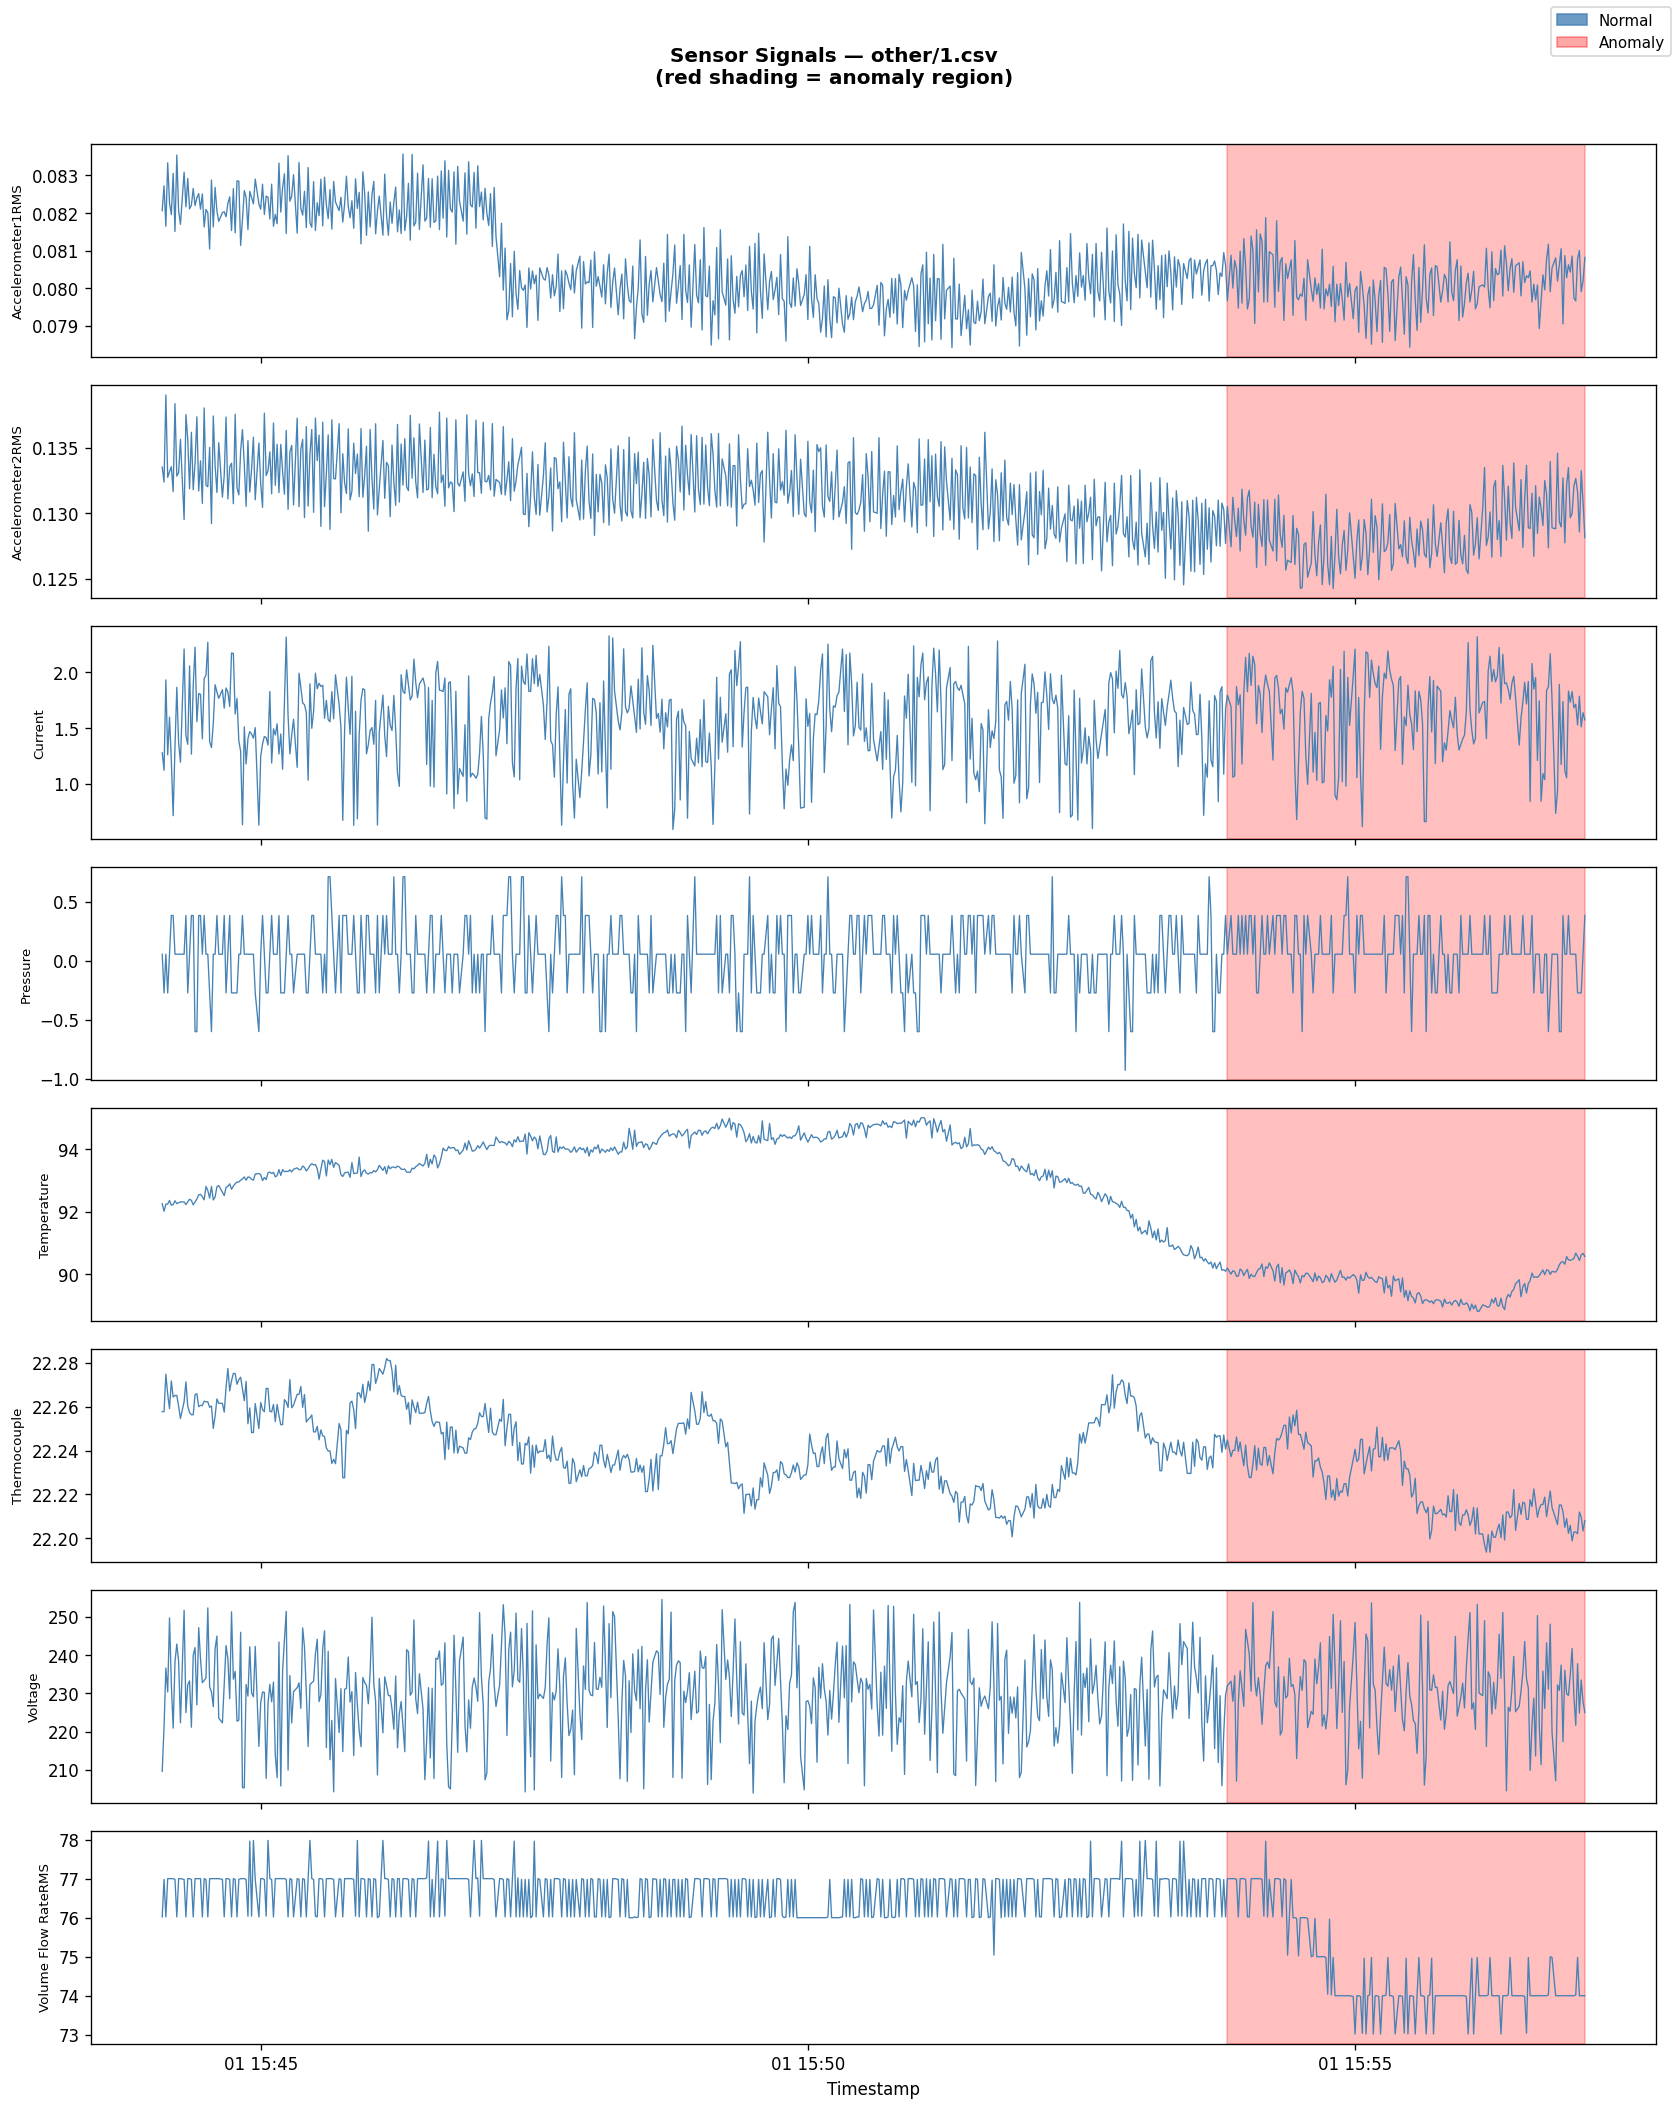

In [22]:
def shade_anomalies(ax, df, label_col=LABEL_COL, color="red", alpha=0.25):
    """Shade contiguous anomaly spans on a matplotlib axis."""
    labels  = df[label_col].values
    idx     = df.index
    in_anom = False
    start   = None
    for i, v in enumerate(labels):
        if v == 1 and not in_anom:
            start   = idx[i]
            in_anom = True
        elif v == 0 and in_anom:
            ax.axvspan(start, idx[i - 1], color=color, alpha=alpha)
            in_anom = False
    if in_anom:                            # anomaly runs to the end of the series
        ax.axvspan(start, idx[-1], color=color, alpha=alpha)


# Choose a file that actually contains anomalies for a richer plot
plot_key = next(
    (k for k, d in raw_data.items() if d[LABEL_COL].sum() > 0), example_key
)
plot_df = raw_data[plot_key]

fig, axes = plt.subplots(len(FEATURE_COLS), 1,
                          figsize=(14, 2.2 * len(FEATURE_COLS)),
                          sharex=True)
fig.suptitle(f"Sensor Signals — {plot_key}\n(red shading = anomaly region)",
             fontsize=12, fontweight="bold")

for ax, col in zip(axes, FEATURE_COLS):
    ax.plot(plot_df.index, plot_df[col], linewidth=0.8, color="steelblue")
    shade_anomalies(ax, plot_df)
    ax.set_ylabel(col, fontsize=8)

axes[-1].set_xlabel("Timestamp")
anom_patch = mpatches.Patch(color="red",       alpha=0.35, label="Anomaly")
norm_patch = mpatches.Patch(color="steelblue", alpha=0.80, label="Normal")
fig.legend(handles=[norm_patch, anom_patch], loc="upper right", fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{OUTPUT_DIR}/skab_sensor_timeseries.png", bbox_inches="tight")
plt.show()

### 2.2 Anomaly label distribution across all 34 files

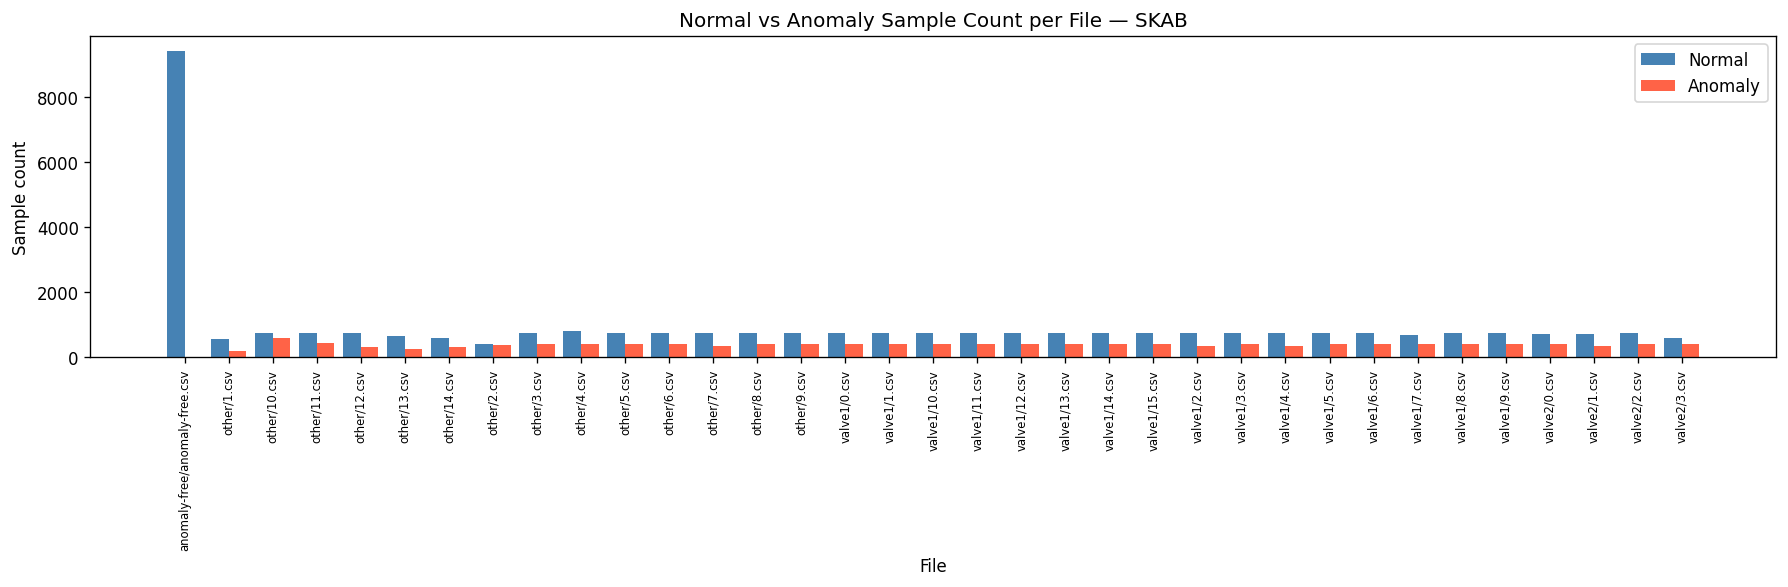

In [23]:
label_stats = []
for key, df in raw_data.items():
    n_total = len(df)
    n_anom  = int(df[LABEL_COL].sum())
    label_stats.append({"file": key, "normal": n_total - n_anom, "anomaly": n_anom})

label_df = pd.DataFrame(label_stats).set_index("file")

fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(label_df))
w = 0.40
ax.bar(x - w/2, label_df["normal"],  width=w, label="Normal",  color="steelblue")
ax.bar(x + w/2, label_df["anomaly"], width=w, label="Anomaly", color="tomato")
ax.set_xticks(x)
ax.set_xticklabels(label_df.index, rotation=90, fontsize=7)
ax.set_xlabel("File")
ax.set_ylabel("Sample count")
ax.set_title("Normal vs Anomaly Sample Count per File — SKAB")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skab_label_distribution.png", bbox_inches="tight")
plt.show()

### 2.3 Correlation heatmap of the 8 sensor features

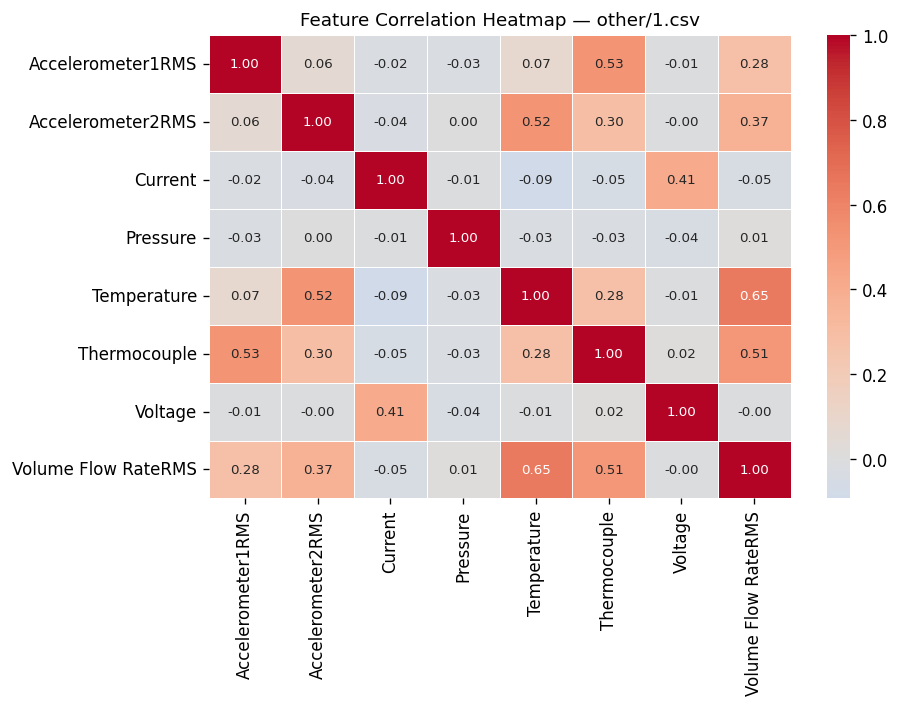

In [24]:
corr = plot_df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title(f"Feature Correlation Heatmap — {plot_key}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skab_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### 2.4 Feature distributions: normal vs anomalous (overlaid histograms)

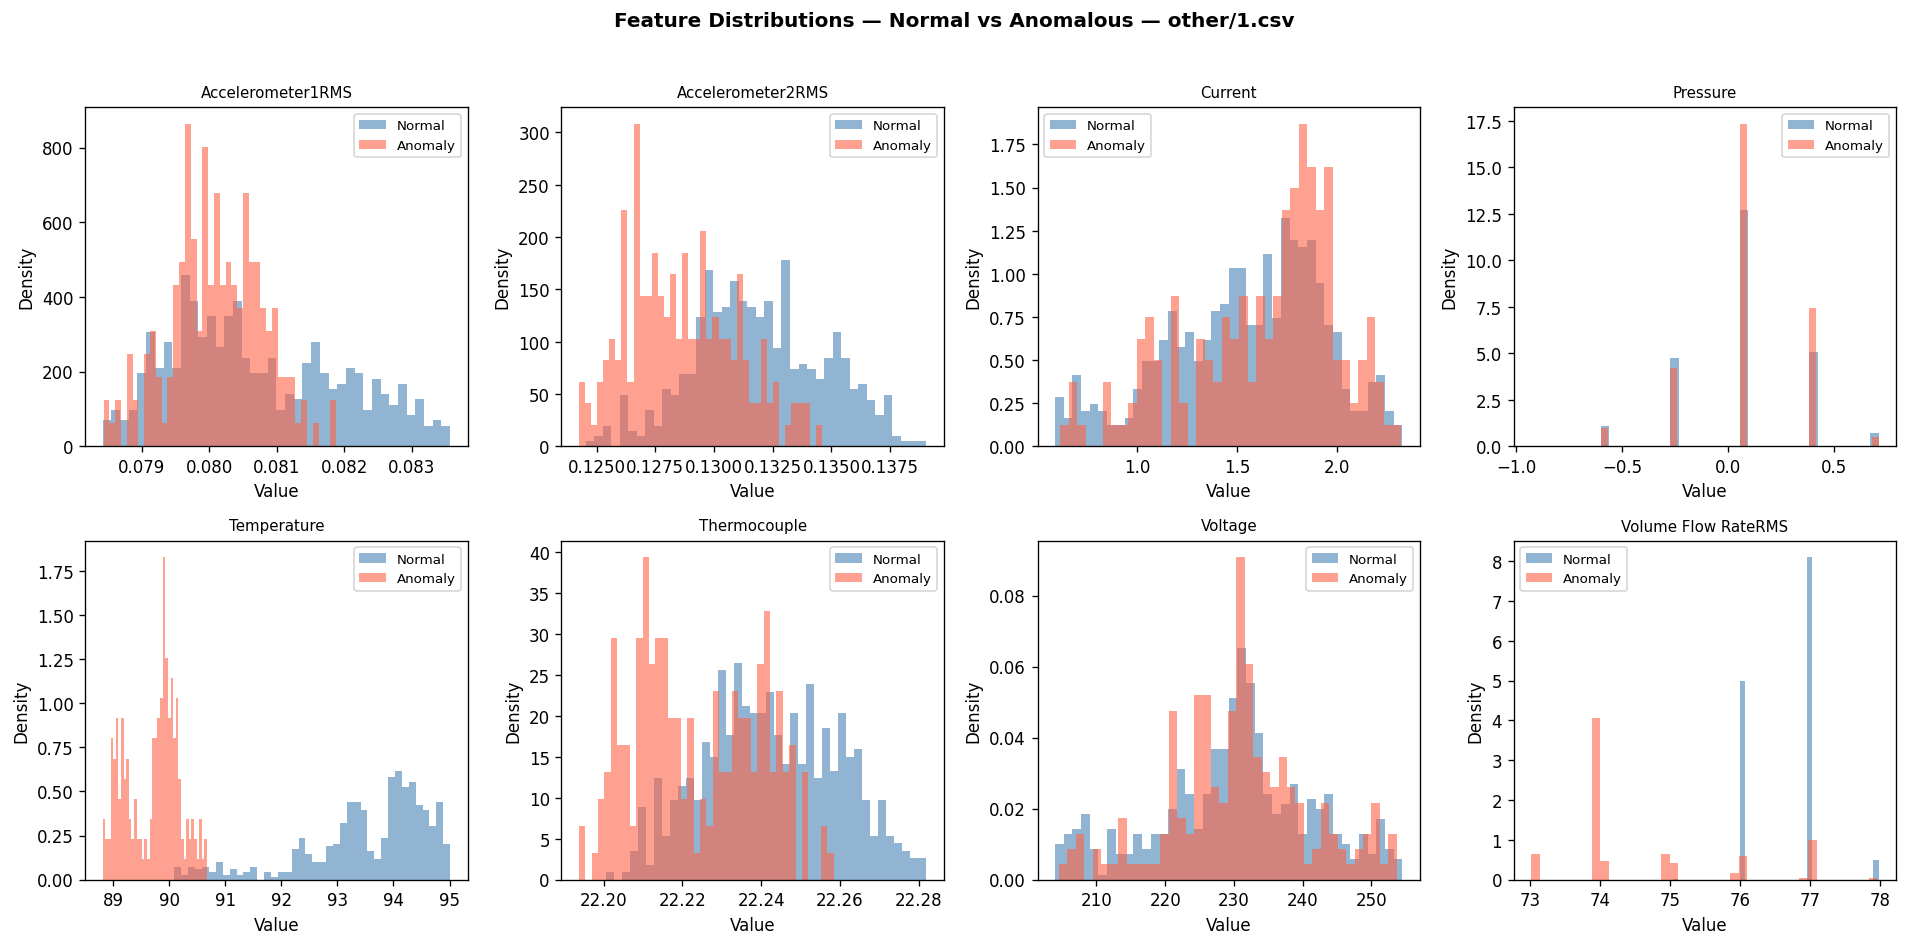

In [25]:
normal_df_plot = plot_df[plot_df[LABEL_COL] == 0]
anom_df_plot   = plot_df[plot_df[LABEL_COL] == 1]

n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat  = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes_flat[i]
    ax.hist(normal_df_plot[col].dropna(), bins=40, alpha=0.6,
            color="steelblue", label="Normal",  density=True)
    ax.hist(anom_df_plot[col].dropna(),   bins=40, alpha=0.6,
            color="tomato",    label="Anomaly", density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f"Feature Distributions — Normal vs Anomalous — {plot_key}",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{OUTPUT_DIR}/skab_feature_distributions.png", bbox_inches="tight")
plt.show()

### 2.5 Overall class balance

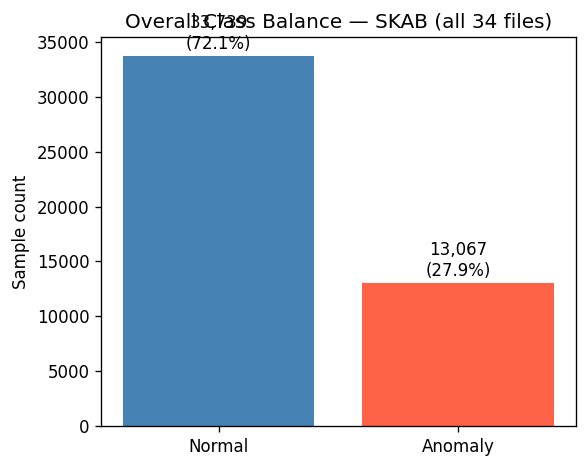


Anomaly rate: 27.92% — do NOT balance this dataset.
Training set will contain normal samples only.
Use F1, AUC-PR as evaluation metrics.


In [26]:
all_labels = pd.concat([d[LABEL_COL] for d in raw_data.values()])
total      = len(all_labels)
n_normal   = int((all_labels == 0).sum())
n_anomaly  = int((all_labels == 1).sum())
anom_pct   = 100 * n_anomaly / total

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Normal", "Anomaly"], [n_normal, n_anomaly],
              color=["steelblue", "tomato"])
for bar, count, pct in zip(bars,
                            [n_normal, n_anomaly],
                            [100 - anom_pct, anom_pct]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Sample count")
ax.set_title("Overall Class Balance — SKAB (all 34 files)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skab_class_balance.png", bbox_inches="tight")
plt.show()

print(f"\nAnomaly rate: {anom_pct:.2f}% — do NOT balance this dataset.")
print("Training set will contain normal samples only.")
print("Use F1, AUC-PR as evaluation metrics.")

> **Why we do NOT balance this dataset**
>
> Anomaly detection with autoencoders is an **unsupervised, reconstruction-based** method.
> The model trains exclusively on normal samples to learn the nominal operating manifold.
> Anomalies are detected at inference time when the reconstruction error exceeds a learned threshold.
>
> Applying SMOTE, oversampling, or undersampling would:
> 1. Contaminate the training distribution with synthetic anomaly signatures, violating the core assumption.
> 2. Inflate evaluation metrics by forcing artificial class symmetry.
> 3. Invalidate the unsupervised framing — the autoencoder must never see anomaly patterns during training.
>
> Correct metrics for this imbalanced setting: **F1-score** and **AUC-PR** (precision-recall curve area).

### 2.6 Per-file summary statistics

In [27]:
print(f"{'File':<40} {'Total':>8} {'Anomaly':>8} {'Anom%':>7}")
print("-" * 68)
for row in label_stats:
    tot = row["normal"] + row["anomaly"]
    pct = 100 * row["anomaly"] / tot if tot > 0 else 0.0
    print(f"{row['file']:<40} {tot:>8,} {row['anomaly']:>8,} {pct:>6.2f}%")
print("-" * 68)
print(f"{'TOTAL':<40} {total:>8,} {n_anomaly:>8,} {anom_pct:>6.2f}%")

File                                        Total  Anomaly   Anom%
--------------------------------------------------------------------
anomaly-free/anomaly-free.csv               9,405        0   0.00%
other/1.csv                                   745      188  25.23%
other/10.csv                                1,327      586  44.16%
other/11.csv                                1,190      451  37.90%
other/12.csv                                1,048      309  29.48%
other/13.csv                                  923      265  28.71%
other/14.csv                                  905      302  33.37%
other/2.csv                                   780      384  49.23%
other/3.csv                                 1,137      398  35.00%
other/4.csv                                 1,191      395  33.17%
other/5.csv                                 1,155      410  35.50%
other/6.csv                                 1,147      402  35.05%
other/7.csv                                 1,090      347  

---
## Section 3 — Preprocessing

### 3.1 Concatenate all files into one DataFrame

In [28]:
frames = []
for key, df in raw_data.items():
    tmp = df.copy()
    tmp["source_file"] = key
    frames.append(tmp)

combined = pd.concat(frames).sort_index()   # preserve chronological order
print(f"Combined shape : {combined.shape}")
print(f"Index dtype    : {combined.index.dtype}")
print(f"Date range     : {combined.index.min()} → {combined.index.max()}")
display(combined.head(3))

Combined shape : (46806, 11)
Index dtype    : datetime64[us]
Date range     : 2020-02-08 13:30:47 → 2020-03-09 17:14:09


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint,source_file
datetime,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,0.382638,90.6454,26.8508,238.852,122.664,0,0,anomaly-free/anomaly-free.csv
2020-02-08 13:30:48,0.203153,0.277857,2.07999,-0.273216,90.7978,26.8639,227.943,122.338,0,0,anomaly-free/anomaly-free.csv
2020-02-08 13:30:50,0.202054,0.275790,2.52577,0.382638,90.7730,26.8603,223.486,121.338,0,0,anomaly-free/anomaly-free.csv


### 3.2 Missing value handling

In [29]:
nan_report = combined[FEATURE_COLS].isna().sum()
print("NaN count per feature column:")
print(nan_report.to_string())

# Forward-fill then backward-fill to handle leading/trailing NaNs
combined[FEATURE_COLS] = combined[FEATURE_COLS].ffill().bfill()

remaining = combined[FEATURE_COLS].isna().sum().sum()
print(f"\nRemaining NaNs after ffill+bfill: {remaining}")
if remaining > 0:
    combined = combined.dropna(subset=FEATURE_COLS)
    print(f"Dropped rows with remaining NaNs. New shape: {combined.shape}")

NaN count per feature column:
Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0

Remaining NaNs after ffill+bfill: 0


### 3.3 Chronological + anomaly-aware split

- **Train (70%)** — normal samples only, chronologically first
- **Validation (10%)** — normal samples only, chronologically next
- **Test (20%)** — remaining normal samples + ALL anomalous samples, re-sorted by time

No shuffling at any stage.

In [30]:
normal_mask    = combined[LABEL_COL] == 0
normal_df_all  = combined[normal_mask].copy()
anom_df_all    = combined[~normal_mask].copy()

n_norm         = len(normal_df_all)
train_end      = int(n_norm * TRAIN_RATIO)
val_end        = int(n_norm * (TRAIN_RATIO + VAL_RATIO))

train_df       = normal_df_all.iloc[:train_end].copy()
val_df         = normal_df_all.iloc[train_end:val_end].copy()
test_normal_df = normal_df_all.iloc[val_end:].copy()

# Merge tail-of-normal + all anomalies, sort chronologically
test_df = pd.concat([test_normal_df, anom_df_all]).sort_index()

print(f"Normal samples total : {n_norm:,}")
print(f"Anomaly samples total: {len(anom_df_all):,}")
print()
print(f"Train  : {len(train_df):,} rows (normal only)")
print(f"Val    : {len(val_df):,} rows (normal only)")
print(f"Test   : {len(test_df):,} rows  "
      f"({int(test_df[LABEL_COL].sum()):,} anomalies = "
      f"{100*test_df[LABEL_COL].mean():.1f}%)")

Normal samples total : 33,739
Anomaly samples total: 13,067

Train  : 23,617 rows (normal only)
Val    : 3,374 rows (normal only)
Test   : 19,815 rows  (13,067 anomalies = 65.9%)


### 3.4 MinMaxScaler — fit on training data only

In [31]:
scaler = MinMaxScaler()
scaler.fit(train_df[FEATURE_COLS])   # fit exclusively on train split

train_scaled = scaler.transform(train_df[FEATURE_COLS])
val_scaled   = scaler.transform(val_df[FEATURE_COLS])
test_scaled  = scaler.transform(test_df[FEATURE_COLS])

train_labels = train_df[LABEL_COL].values.astype(np.int8)
val_labels   = val_df[LABEL_COL].values.astype(np.int8)
test_labels  = test_df[LABEL_COL].values.astype(np.int8)

print("Scaled array shapes:")
print(f"  train : {train_scaled.shape}")
print(f"  val   : {val_scaled.shape}")
print(f"  test  : {test_scaled.shape}")

Scaled array shapes:
  train : (23617, 8)
  val   : (3374, 8)
  test  : (19815, 8)


### 3.5 Sliding window transformation

Applied **after** splitting to prevent data leakage across split boundaries.  
Window label = 1 if **any** timestep within the window is anomalous.

In [32]:
def sliding_window(X: np.ndarray, y: np.ndarray,
                   window_size: int, step_size: int):
    """Segment a 2-D array into overlapping windows.

    Returns:
        X_win : (n_windows, window_size, n_features)
        y_win : (n_windows,)  1 if any step in the window is anomalous
    """
    windows_X, windows_y = [], []
    n = len(X)
    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        windows_X.append(X[start:end])
        windows_y.append(int(y[start:end].any()))
    return (np.array(windows_X, dtype=np.float32),
            np.array(windows_y, dtype=np.int8))


X_train, y_train = sliding_window(train_scaled, train_labels, WINDOW_SIZE, STEP_SIZE)
X_val,   y_val   = sliding_window(val_scaled,   val_labels,   WINDOW_SIZE, STEP_SIZE)
X_test,  y_test  = sliding_window(test_scaled,  test_labels,  WINDOW_SIZE, STEP_SIZE)

print("Final windowed shapes:")
print(f"  X_train : {X_train.shape}  y_train anomalies : "
      f"{y_train.sum()} ({100*y_train.mean():.2f}%)")
print(f"  X_val   : {X_val.shape}  y_val anomalies   : "
      f"{y_val.sum()} ({100*y_val.mean():.2f}%)")
print(f"  X_test  : {X_test.shape}  y_test anomalies  : "
      f"{y_test.sum()} ({100*y_test.mean():.2f}%)")

Final windowed shapes:
  X_train : (23588, 30, 8)  y_train anomalies : 0 (0.00%)
  X_val   : (3345, 30, 8)  y_val anomalies   : 0 (0.00%)
  X_test  : (19786, 30, 8)  y_test anomalies  : 13357 (67.51%)


### 3.6 Save numpy arrays locally

In [33]:
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val",   y_val), ("y_test",  y_test)]:
    path = os.path.join(NPY_DIR, f"{name}.npy")
    np.save(path, arr)
    print(f"Saved {path}  shape={arr.shape}")

Saved npy_skab/X_train.npy  shape=(23588, 30, 8)
Saved npy_skab/X_val.npy  shape=(3345, 30, 8)
Saved npy_skab/X_test.npy  shape=(19786, 30, 8)
Saved npy_skab/y_train.npy  shape=(23588,)
Saved npy_skab/y_val.npy  shape=(3345,)
Saved npy_skab/y_test.npy  shape=(19786,)


---
## Section 4 — Validation Plots

### 4.1 Original vs normalised signal

NameError: name 'train_df' is not defined

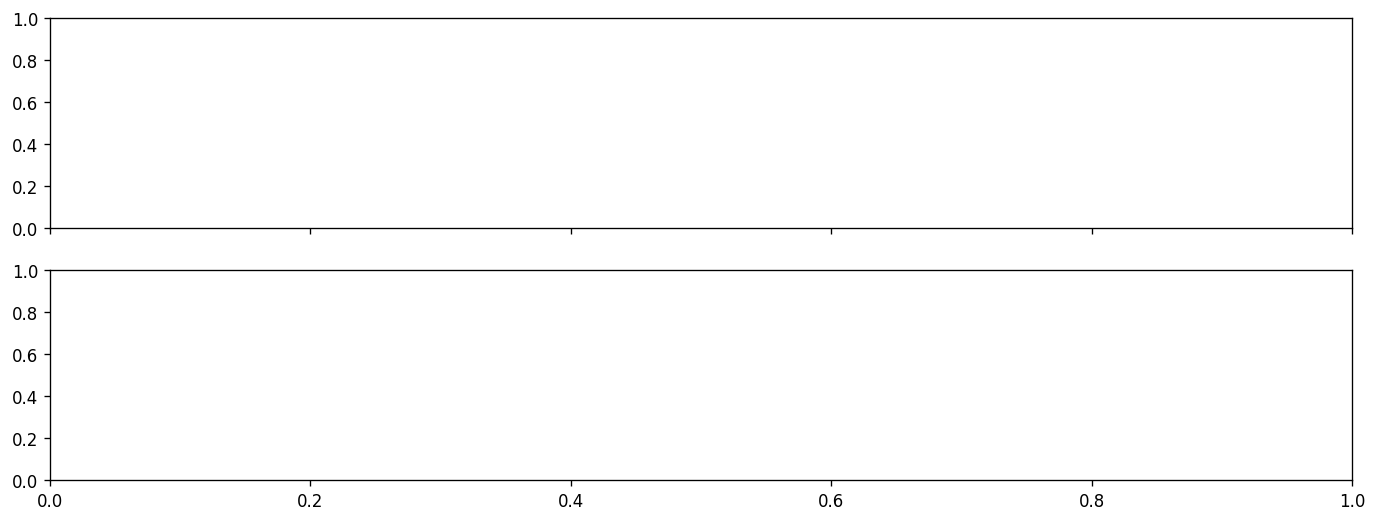

In [6]:
feat_idx = 0     # index into FEATURE_COLS
n_show   = 500   # timesteps to display

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(train_df[FEATURE_COLS[feat_idx]].values[:n_show],
             color="steelblue", linewidth=0.9)
axes[0].set_title(f"Original Signal — {FEATURE_COLS[feat_idx]} "
                  f"(first {n_show} train timesteps)")
axes[0].set_ylabel("Raw value")

axes[1].plot(train_scaled[:n_show, feat_idx],
             color="darkorange", linewidth=0.9)
axes[1].set_title(f"MinMax Normalised — {FEATURE_COLS[feat_idx]}")
axes[1].set_ylabel("Scaled [0, 1]")
axes[1].set_xlabel("Timestep")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skab_normalisation_check.png", bbox_inches="tight")
plt.show()

### 4.2 Split boundaries on the combined time-series

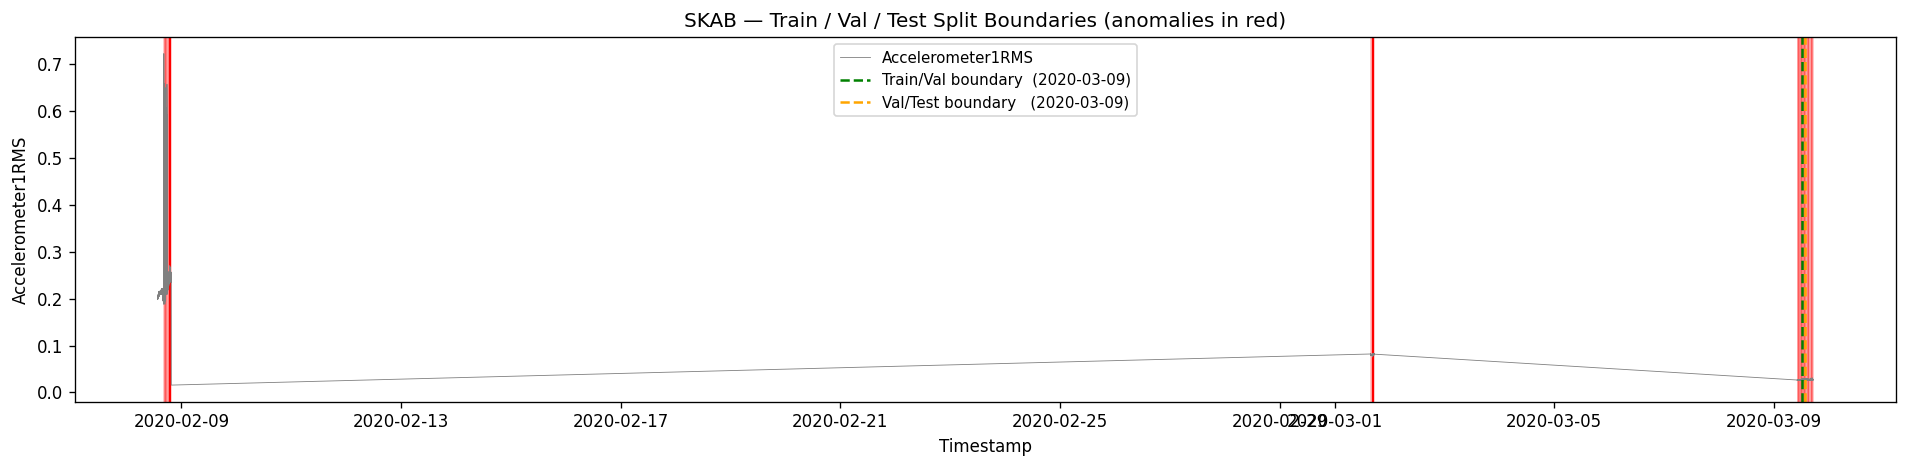

In [35]:
vis_col   = FEATURE_COLS[0]

# Use start of next split as boundary (not end of current) so close-together
# intra-day boundaries are plotted at the correct distinct positions.
train_val_boundary = val_df.index[0]
val_test_boundary  = test_normal_df.index[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7),
                                gridspec_kw={'height_ratios': [1, 1.2]})
fig.suptitle('SKAB — Train / Val / Test Split Boundaries', fontsize=13, fontweight='bold')

# Panel 1: full timeline
ax1.plot(combined.index, combined[vis_col], linewidth=0.4, color='grey')
shade_anomalies(ax1, combined)
ax1.axvspan(train_df.index[0],       train_df.index[-1],       alpha=0.12, color='steelblue')
ax1.axvspan(val_df.index[0],         val_df.index[-1],         alpha=0.20, color='green')
ax1.axvspan(test_normal_df.index[0], test_normal_df.index[-1], alpha=0.12, color='orange')
ax1.axvline(train_val_boundary, color='green',  linestyle='--', linewidth=1.5)
ax1.axvline(val_test_boundary,  color='orange', linestyle='--', linewidth=1.5)
ax1.set_ylabel(vis_col)
ax1.set_title('Full timeline  (anomalies in red)', fontsize=10)
handles = [
    mpatches.Patch(color='steelblue', alpha=0.4, label='Train (normal)'),
    mpatches.Patch(color='green',     alpha=0.4, label='Val (normal)'),
    mpatches.Patch(color='orange',    alpha=0.4, label='Test-normal'),
    mpatches.Patch(color='red',       alpha=0.3, label='Anomalies (→ test)'),
]
ax1.legend(handles=handles, fontsize=8, loc='upper right')

# Panel 2: zoom into the experiment day where boundaries fall
march9 = combined[combined.index >= pd.Timestamp('2020-03-09')]
ax2.plot(march9.index, march9[vis_col], linewidth=0.5, color='grey')
shade_anomalies(ax2, march9)
ax2.axvline(train_val_boundary, color='green',  linestyle='--', linewidth=2.0,
            label=f"Train/Val  ({train_val_boundary.strftime('%H:%M:%S')})")
ax2.axvline(val_test_boundary,  color='orange', linestyle='--', linewidth=2.0,
            label=f"Val/Test   ({val_test_boundary.strftime('%H:%M:%S')})")
ax2.axvspan(march9.index[0],    train_val_boundary, alpha=0.12, color='steelblue')
ax2.axvspan(train_val_boundary, val_test_boundary,  alpha=0.20, color='green')
ax2.axvspan(val_test_boundary,  march9.index[-1],   alpha=0.12, color='orange')
ax2.set_xlabel('Timestamp (March 9, 2020)')
ax2.set_ylabel(vis_col)
ax2.set_title('Zoom: March 9, 2020 — where val/test boundaries lie', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{OUTPUT_DIR}/skab_split_boundaries.png", bbox_inches='tight')
plt.show()


### 4.3 Test set class balance (window level)

In [1]:
test_norm_cnt = int((y_test == 0).sum())
test_anom_cnt = int((y_test == 1).sum())
test_total    = len(y_test)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Normal", "Anomaly"],
              [test_norm_cnt, test_anom_cnt],
              color=["steelblue", "tomato"])
for bar, cnt in zip(bars, [test_norm_cnt, test_anom_cnt]):
    pct = 100 * cnt / test_total
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + test_total * 0.005,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Window count")
ax.set_title("Test Set Class Balance — SKAB (sliding windows)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skab_test_class_balance.png", bbox_inches="tight")
plt.show()

NameError: name 'y_test' is not defined

---
## Section 5 — Push to Hugging Face Hub

Credentials are loaded from `.env`. Make sure `HF_USERNAME` and `HF_TOKEN` are set there before running this section.

In [7]:
def arrays_to_hf_dict(X: np.ndarray, y: np.ndarray) -> dict:
    """Flatten (n_windows, window_size, n_features) for HuggingFace Dataset.

    Each feature becomes a column of lists (one list per window).
    """
    n_windows, ws, n_feat = X.shape
    d = {f"feature_{i}": X[:, :, i].tolist() for i in range(n_feat)}
    d["label"] = y.tolist()
    return d


hf_train = Dataset.from_dict(arrays_to_hf_dict(X_train, y_train))
hf_val   = Dataset.from_dict(arrays_to_hf_dict(X_val,   y_val))
hf_test  = Dataset.from_dict(arrays_to_hf_dict(X_test,  y_test))

dataset_dict = DatasetDict({
    "train":      hf_train,
    "validation": hf_val,
    "test":       hf_test,
})
print(dataset_dict)

NameError: name 'X_train' is not defined

In [ ]:
# Persist metadata alongside the dataset
metadata = {
    "dataset_name"      : "SKAB (Skoltech Anomaly Benchmark)",
    "description"       : (
        "Multivariate IIoT water-pump time-series. "
        "Preprocessed with chronological + anomaly-aware split. "
        "Sliding window applied after splitting to prevent leakage."
    ),
    "feature_columns"   : FEATURE_COLS,
    "label_column"      : "label",
    "window_size"       : WINDOW_SIZE,
    "step_size"         : STEP_SIZE,
    "train_ratio"       : TRAIN_RATIO,
    "val_ratio"         : VAL_RATIO,
    "scaler"            : "MinMaxScaler fitted on train split only",
    "n_train_windows"   : int(X_train.shape[0]),
    "n_val_windows"     : int(X_val.shape[0]),
    "n_test_windows"    : int(X_test.shape[0]),
    "anomaly_rate_test" : float(round(y_test.mean(), 4)),
    "source"            : "https://github.com/waico/SKAB",
}

meta_path = os.path.join(OUTPUT_DIR, "skab_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to {meta_path}")
print(json.dumps(metadata, indent=2))

In [ ]:
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"

dataset_dict.push_to_hub(
    repo_id,
    token=HF_TOKEN,
    commit_message="Add SKAB preprocessed sliding-window dataset",
)
print(f"\nDataset pushed to: https://huggingface.co/datasets/{repo_id}")

### Loading the dataset in Google Colab

```python
from datasets import load_dataset
import numpy as np

ds = load_dataset("YOUR_HF_USERNAME/skab-anomaly-detection")

# Reconstruct numpy arrays from the flattened HF representation
def split_to_arrays(split, n_features=8):
    # Stack per-feature columns → (n_windows, window_size, n_features)
    X = np.stack(
        [np.array(split[f"feature_{i}"]) for i in range(n_features)],
        axis=-1
    )
    y = np.array(split["label"])
    return X, y

X_train, y_train = split_to_arrays(ds["train"])
X_val,   y_val   = split_to_arrays(ds["validation"])
X_test,  y_test  = split_to_arrays(ds["test"])

print(X_train.shape, X_val.shape, X_test.shape)
# → (n_train, 30, 8)  (n_val, 30, 8)  (n_test, 30, 8)
```

---
## Final Summary

In [ ]:
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"

print("=" * 60)
print(" SKAB Preprocessing — Final Summary")
print("=" * 60)
print(f" Dataset          : SKAB (Skoltech Anomaly Benchmark)")
print(f" Source files     : {len(raw_data)} CSV files")
print(f" Features         : {len(FEATURE_COLS)} sensor channels")
print(f" Window size      : {WINDOW_SIZE}   Step size: {STEP_SIZE}")
print(f" Train windows    : {X_train.shape[0]:,}  (normal only)")
print(f" Val windows      : {X_val.shape[0]:,}   (normal only)")
print(f" Test windows     : {X_test.shape[0]:,}")
print(f" Anomaly rate     : {100*y_test.mean():.2f}% in test split")
print(f" HF dataset URL   : https://huggingface.co/datasets/{repo_id}")
print("=" * 60)